# **Manual Construction of Convolutional Filters in Keras**
The goal of this project is to implement a simple Convolutional Neural Network (CNN) in Keras where the values of the kernels in a convolutional layer are manually defined. These kernels are designed to detect specific patterns in images, such as edges.

Additionally, the outputs produced after the convolutional layer and after the max pooling layer are visualized and compared to analyze how each operation transforms the image representation. 

In this project we build a simple CNN that includes:

* An input layer for images
* A convolutional layer with manually defined filters
* A max pooling layer

The manually defined filters are designed to detect patterns such as:

* Vertical edges
* Horizontal edges
* Diagonal edges
* Strong intensity changes

After applying the model to a test image, we visualize:

1. The original image
2. The output of each filter after the convolutional layer
3. The output after the max pooling layer



## **01 Libraries**

In [2]:
print("Loading libraries...")
from keras.models import Sequential
from tensorflow.keras.models import Model
from keras.layers import Flatten, Dense, Dropout, Conv2D, MaxPooling2D, ZeroPadding2D
from tensorflow.keras.preprocessing import image
from keras.optimizers import SGD
import numpy as np
import matplotlib.pyplot as plt
print("Done!")

Loading libraries...
Done!


## **02 Load Image**


In [82]:
img = image.load_img("test_image.jpg", target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
print(img_array.shape)

(1, 224, 224, 3)


Displaying original image...


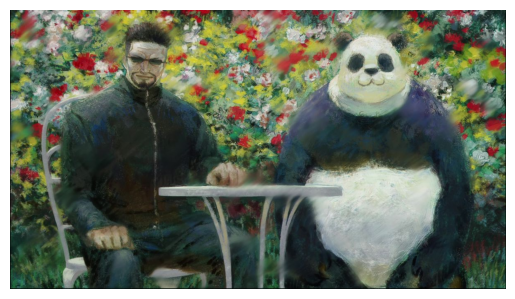

In [83]:
original_image = image.load_img("test_image.jpg",)
or_img_array = image.img_to_array(original_image)
or_img_array = or_img_array / 255.0
or_img_array = np.expand_dims(or_img_array, axis=0)

print("Displaying original image...")
plt.imshow(or_img_array[0])
plt.axis("off")
plt.show()

Displaying image...


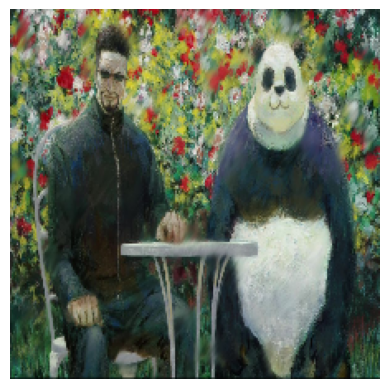

In [84]:
print("Displaying image...")
plt.imshow(img_array[0])
plt.axis("off")
plt.show()

# **1. Convolutional Neural Network (CNN)?**

A Convolutional Neural Network (CNN) is a type of deep learning model designed specifically for processing image data. CNNs are widely used in computer vision tasks such as: image classification, object detection, facial recognition or medical image analysis.

Instead of analyzing images as flat vectors, CNNs preserve the spatial structure of images. They achieve this by applying convolution operations using small matrices called **filters** that scan across the image to detect patterns.


In this project, the focus is on understanding the behavior of convolution and pooling operations.



### **Max Pooling**

Max pooling is a downsampling operation used in CNNs to reduce the spatial dimensions of feature maps.
It works by dividing the feature map into small regions (for example **2×2 windows**) and selecting the maximum value within each region.

Max pooling provides several benefits:

* Reduces the size of the feature maps
* Keeps the most important features
* Improves computational efficiency
* Provides some translation invariance

In [91]:
model = Sequential()

model.add(
    Conv2D(
        filters=6,
        kernel_size=(3,3),
        padding="same",
        input_shape=(224,224,3),
        use_bias=False
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 224, 224, 6)       162       
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 112, 112, 6)       0         
 g2D)                                                            
                                                                 
Total params: 162 (648.00 Byte)
Trainable params: 162 (648.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________



# **2. Filter (Kernel)**

A **filter**, also called a **kernel**, is a small matrix of numbers used in the convolution operation.

The filter slides across the image and performs element-wise multiplication between its values and the corresponding pixels in the image. The results are summed to produce a new pixel value in the output.

This operation generates a feature map, which highlights specific patterns detected by the filter.

Different filters can detect different features, such as:

* Vertical edges
* Horizontal edges
* Diagonal edges
* Texture patterns
* Sudden intensity changes

Example of a simple edge-detection filter:

```
[-1  0  1
 -1  0  1
 -1  0  1]
```

This filter emphasizes vertical edges by detecting strong intensity changes along the horizontal direction. In this activity, instead of letting the neural network learn the filters automatically, the filters are **manually defined** to detect specific visual patterns.


In [92]:
filters = np.zeros((3,3,3,6))

vertical = [[-1,0,1],
            [-2,0,2],
            [-1,0,1]]

horizontal = [[-1,-2,-1],
              [0,0,0],
              [1,2,1]]

diagonal = [[0,1,2],
            [-1,0,1],
            [-2,-1,0]]

sharpen = [[0,-1,0],
           [-1,5,-1],
           [0,-1,0]]

emboss = [[-2,-1,0],
          [-1,1,1],
          [0,1,2]]

gaussian = np.array([[1,2,1],
                     [2,4,2],
                     [1,2,1]]) / 16


| Filter | Purpose |
|------|------|
| Vertical | Detects vertical edges |
| Horizontal | Detects horizontal edges |
| Diagonal | Detects slanted edges |
| Sharpen | Enhances fine details |
| Emboss | Highlights contours and shapes |
| Gaussian | Smooths the image |

In [93]:
kernels = [vertical, horizontal, diagonal, sharpen, emboss, gaussian]

for i,k in enumerate(kernels):
    filters[:,:,0,i] = k
    filters[:,:,1,i] = k
    filters[:,:,2,i] = k

In [94]:
filters = filters.astype(np.float32)
model.layers[0].set_weights([filters])

In [95]:
conv_layer = model.layers[0].output
pool_layer = model.layers[1].output

visualization_model = Model(
    inputs=model.input,
    outputs=[conv_layer, pool_layer]
)

In [96]:
conv_output, pool_output = visualization_model.predict(img_array)

1/1 [==============================] - 0s 82ms/step


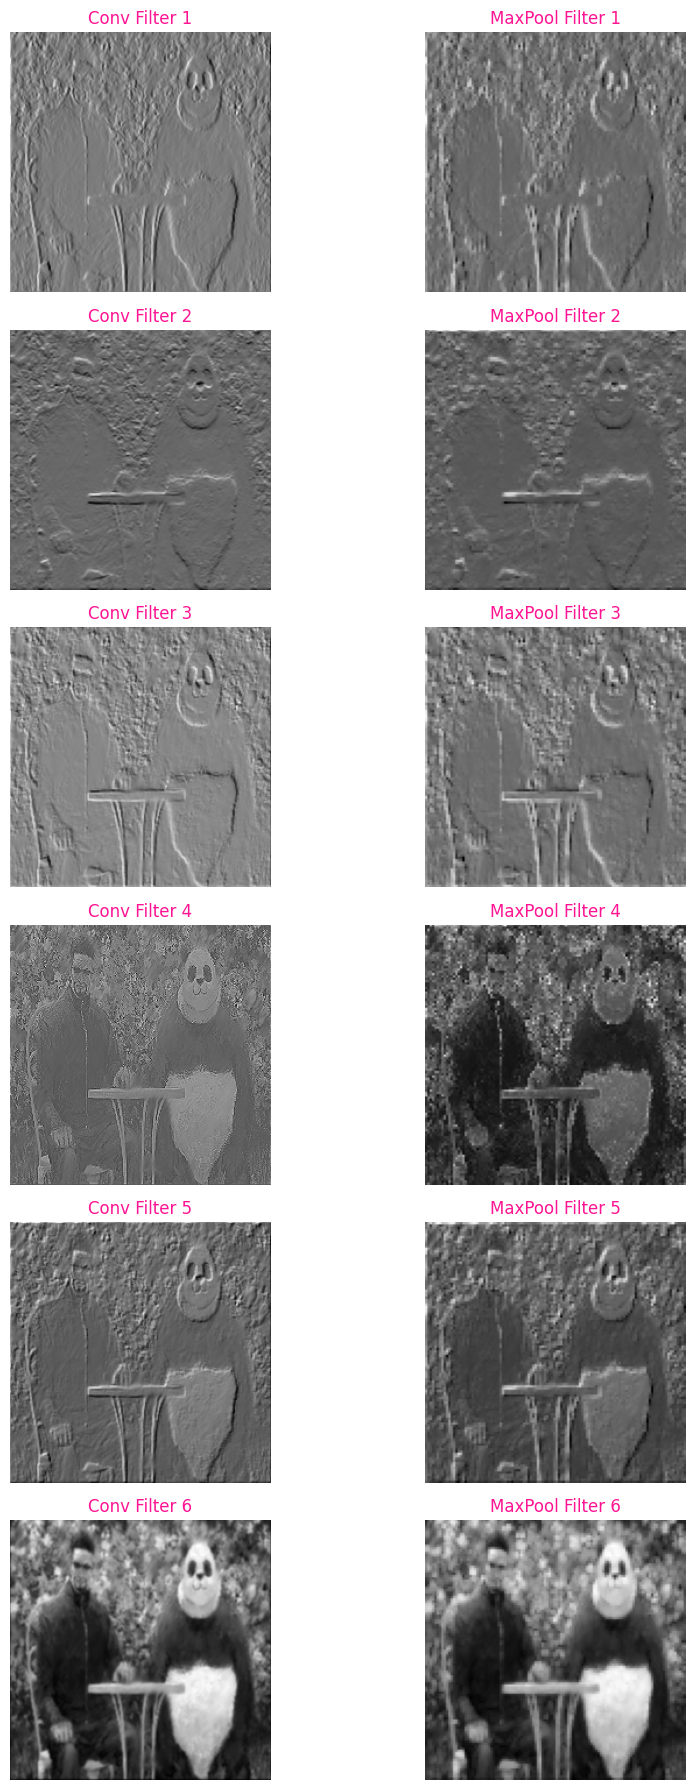

In [97]:
num_filters = 6

plt.figure(figsize=(10, 3 * num_filters))

for i in range(num_filters):
    
    # LEFT: Convolution output
    plt.subplot(num_filters, 2, 2*i + 1)
    plt.imshow(conv_output[0, :, :, i], cmap="gray")
    plt.title(f"Conv Filter {i+1}", color="deeppink", fontsize=12)
    plt.axis("off")
    
    # RIGHT: MaxPooling output
    plt.subplot(num_filters, 2, 2*i + 2)
    plt.imshow(pool_output[0, :, :, i], cmap="gray")
    plt.title(f"MaxPool Filter {i+1}", color="deeppink", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [98]:
print("Conv shape:", conv_output.shape)
print("Pool shape:", pool_output.shape)

Conv shape: (1, 224, 224, 6)
Pool shape: (1, 112, 112, 6)


# **Comparison and Analysis**

Each filter in the convolution layer is designed to detect a specific visual pattern in the image.

* Filter 1 (Vertical edge detection) highlights vertical structures such as the outlines of the people and the edges of the table.
* Filter 2 (Horizontal edge detection) emphasizes horizontal lines such as the top of the table.
* Filter 3 (Diagonal edge detection) captures diagonal contours and transitions in the image.
* Filter 4 (Sharpen filter) enhances fine details and increases the contrast of edges.
* Filter 5 (Emboss filter) emphasizes contours and gives a relief-like effect that highlights shapes and boundaries.
* Filter 6 (Gaussian blur) smooths the image and reduces small details while preserving the overall structure.

Max pooling preserves the strongest activations within each pooling region.
This means the most important features detected by the convolution filters—such as strong edges or prominent shapes—remain visible after pooling. For example, the main contours of the person, panda, and table remain clearly identifiable after max pooling. However, small variations, weak edges, and minor textures may disappear because pooling keeps only the maximum value in each region.



The convolution layer keeps the original spatial dimensions of the image:

```
Convolution output: 224 × 224
```

After applying max pooling with a **2×2 window**, the size is reduced:

```
Max pooling output: 112 × 112
```

This reduction decreases the amount of data while maintaining the most important features.


Max pooling is useful because it reduces the spatial size of feature maps, it has lowers computational cost, and can removes small variations or noise. These properties help convolutional neural networks focus on important patterns while simplifying the representation of the image.


